# Imports and global constants

In [1]:
from textwrap import dedent
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# global constant
STATE=73

# Dark theme for plots ᕙ(▀̿ĺ̯▀̿ ̿)ᕗ
plt.style.use("dark_background")


In [2]:
def read_data(path):
    """
    Reads file into pandas dataframe based on limited file extensions.
    ------------------------------------------------
    INPUT:
        path: (str) Path (absolute/relative) to data file.

    OUTPUT:
        dframe: (pd.DataFrame) Dataframe of the dataset
    """
    # input validation
    if not isinstance(path, str):
        raise ValueError("Path provided not correct datatype!\nMust be a string (asolute path/relative path)")

    try:
        # csv/txt files
        if path.endswith("csv") or path.endswith("txt"):
            dframe = pd.read_csv(path)

        elif path.endswith("dat"):
            dframe = pd.read_csv(path, sep=r"\s+")

    except Exception as err:
        print(f"\nOOPZ!\n{err}")


    return dframe

def split_feats_target(dataframe, target):
    """
    Splits dataframe into predictors and binary target.
    ------------------------------------------
    INPUT:
        dataframe: (pd.DataFrame) 
        target: (pd.Series)

    OUTPUT:
        (tuple)
        X: (pd.DataFrame) Features
        y: (pd.Series) Target
    """
    X = dataframe.drop(columns=[target]).copy()
    # Encode values t
    y = dataframe[target].astype(int).copy()

    return X, y

def get_feature_types(X, threshold=0.05, manual_cats=None):
    """
    Differentiate between numeric and categorical data types
    ------------------------------------------
    INPUT:
        X: (pd.DataFrame) Features
        threshold: (float) Threshold used for locating catetgorical datatypes via cardinality ratio
        manual_cats: (list or None) Manual entries of categorical columns if needed

    OUTPUT:
        (tuple)
        numeric_feats: ()
        categorical_feats: ()
    """
    # Locate categorical data
    if not manual_cats:
        manual_cats = []

    categorical_feats, numeric_feats = [], []

    for col in X.columns:
        # manual override dominates
        if col in manual_cats:
            categorical_feats.append(col)
            continue

        # Based on dtypes
        if X[col].dtype == "object" or X[col].dtype == "bool":
            categorical_feats.append(col)
            continue

        # Cardinality ratio for remaining numeric columns
        cardinal_ratio = X[col].nunique() / len(X)
        
        if cardinal_ratio < threshold:
            categorical_feats.append(col)

        else:
            numeric_feats.append(col)

    return numeric_feats, categorical_feats


# SVM worklfow

In [4]:
def preprocessor(numeric, categorical):
    """
    Numeric types get standard scaling via Normalization: z = (x - mu)/sigma.
    Catgeorical types get One-HOt encoding, converting each category into
    indicator columns.

    ColumnTransformer converts the raw table of values into a numerical
    representation which the SVM needs.
    ------------------------------------------
    INPUT:
        numeric: (list) Numeric column names
        categorical: (list) Categorical column names

    OUTPUT:
        (ColumnTransformer) Fitted transformer that scales numeric and one-hot
        encodes categorical
    """
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
        ]
    )

def build_pipeline(preprocess):
    """
    A Pipeline is a way to chain multiple operations into a final
    mathematical object, as if it's like a single model.
    Applying a list of transformers to the preprocessed data.
    
    PURPOSE: To assemble multiple steps to be cross-validated together while 
    setting different parameters.

    Support Vector Classifier (SVC) attempts to separate classes by finding a
    boundary that best differentiates between the classes.
    For Binary classification:
        f(x) > 0 -> positive class
        f(x) < 0 -> negative class

    (The "support" vectors "hold up" the decision boundaries)
    ---------------------------------------------
    INPUT:
        preprocess: (ColumnTransformer) Preprocessing transformer

    OUTPUT:
        (Pipeline) sklearn pipeline w/ preprocessing and SVM classifier steps
    """
    return Pipeline(
        steps=[
            # Preprocessing step
            ("prep", preprocess),

            # Learning algorithm
            (
                "svm",

                # Support Vector Classifier 
                SVC(
                    # 
                    kernel="rbf",
                    class_weight="balanced",
                    probability=False,
                    max_iter=-1,
                    random_state=STATE,
                ),
            ),
        ]
    )

def param_grid():
    """
    Hyperparameter grid (search space of model settings)
    """
    return [
        {
            "svm__kernel": ["linear"],
            "svm__C": [0.1, 1, 10]
        },
        {
            "svm__kernel": ["rbf"],
            "svm__C": [0.1, 1, 10],
            "svm__gamma": ["scale", 0.01],

        }
    ]

def tuning(
    pipeline,
    param_grid,
    X_train,
    y_train
):
    """
    Tunes model via GridSearchCV using F1-Score result of class imabalance
    -------------------------------------------------
    INPUT:
        pipeline: (Pipeline) Sklearn pipeline w/ preprocessing & classifier
        steps
        param_grid: (list of dicts) Hyperparameter search space for
        GridSearchCV
        X_train: (pd.DataFrame) Training features
        y_train: (pd.Series) Training target

    OUTPUT:
        grid; (GridSearchCV) Fitted grid search object containing the best
        estimator and CV results
    """
    # THE GRID
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=3,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
    )

    grid.fit(X_train, y_train)
    return grid

def permutation_importancez(model, X_test, y_test, top_n=15):
    """
    Computes permutation importance
    """
    result = permutation_importance(
        estimator=model,
        X=X_test,
        y=y_test,
        scoring="f1",
        n_repeats=5,
        random_state=STATE,
        n_jobs=-1,
    )

    importance_df = pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": result.importances_mean,
            "importance_std": result.importances_std,
        }
    ).sort_values(by="importance_mean", ascending=False)

    top_feats = importance_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 7))
    plt.barh(top_feats["feature"], top_feats["importance_mean"], color="lime")
    plt.xlabel("Mean Permutation Importance (Decrease in F1)")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Permutation Importances")
    plt.tight_layout()
    plt.grid(color="violet")
    plt.show()

    return importance_df



# Model evaluation and plots


FEATURE TYPE SUMMARY
---------------------
Numerical features (6: ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues'])
Categorical features (11: ['Administrative', 'Informational', 'ProductRelated', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend'])


TRAIN/TEST SPLIT
----------------
X_train shape: (9864, 17)
X_test shape: (2466, 17)
y_train shape: (9864,)
y_test shape: (2466,)

Fitting 3 folds for each of 9 candidates, totalling 27 fits

HYPERPARAMETER TUNING
--------------------
Best parameters: {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV F1-Score: 0.642



MODEL PERFORMANCE ON TEST SET
----------------------------
ACCRUACY: 0.876
PRECISION: 0.577
RECALL: 0.738
F1-SCORE: 0.648
ROC-AUC: 0.909



    CONFUSION MATRIX:
[[1877  207]
 [ 100  282]]

    CLASSIFICATION REPORT:
                  precision    recall  f1-score   support

          

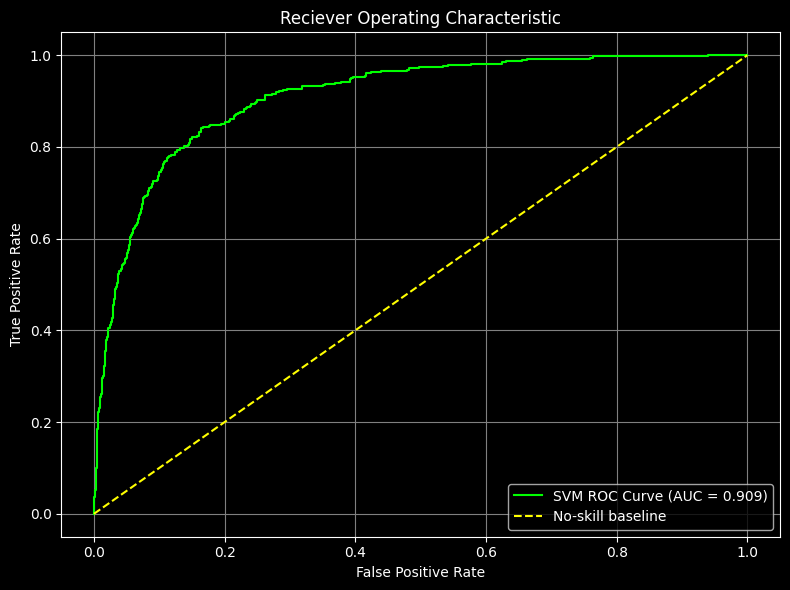

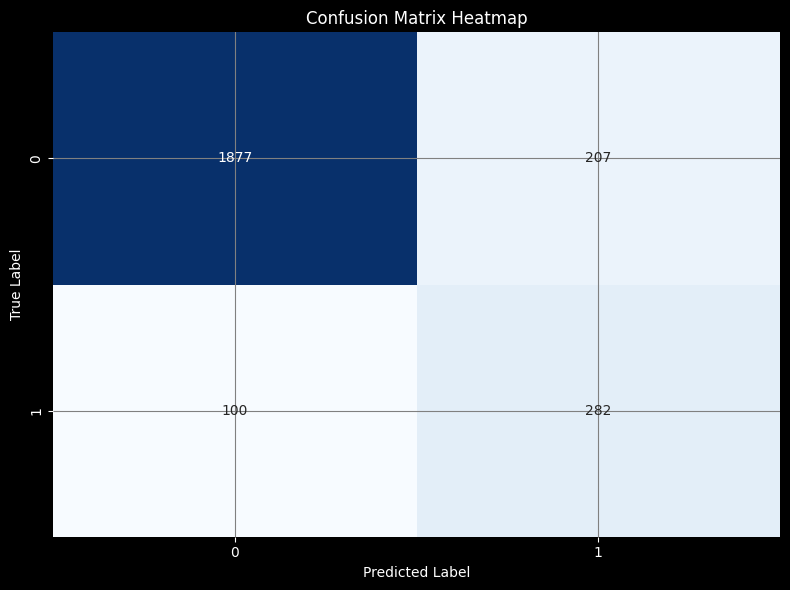

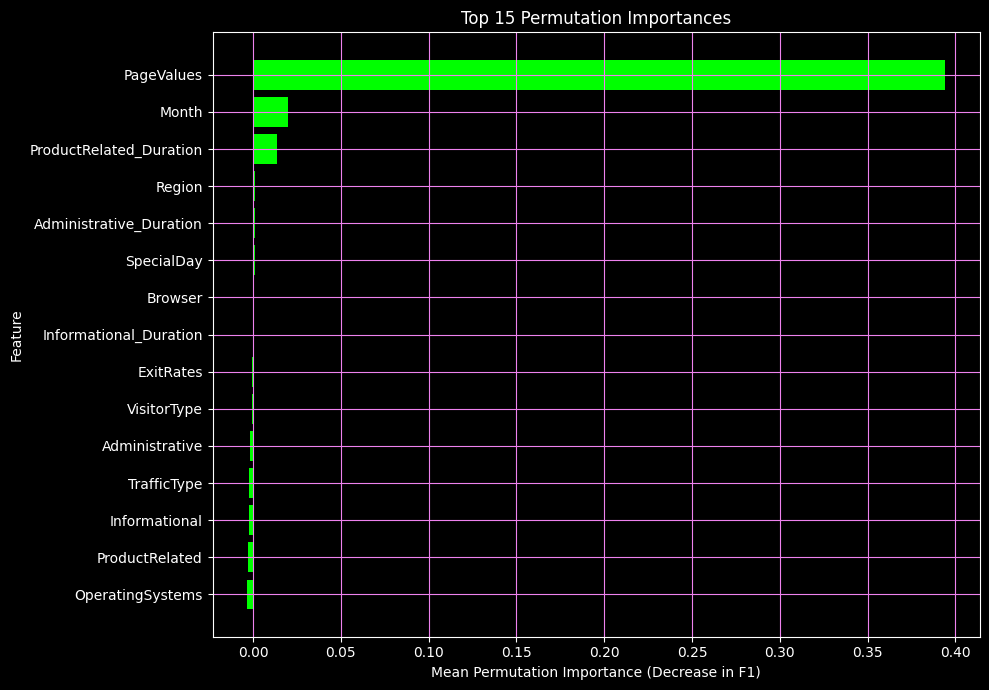


TOP 15 PERMUTATION IMPORTANCES
-----------------------------
                feature  importance_mean  importance_std
             PageValues         0.394207        0.008609
                  Month         0.019600        0.007227
ProductRelated_Duration         0.013442        0.002399
                 Region         0.001271        0.002593
Administrative_Duration         0.000985        0.000411
             SpecialDay         0.000905        0.000753
                Browser         0.000477        0.001478
 Informational_Duration        -0.000069        0.001650
              ExitRates        -0.000674        0.004592
            VisitorType        -0.000931        0.000760
         Administrative        -0.001576        0.002934
            TrafficType        -0.002205        0.003167
          Informational        -0.002643        0.001577
         ProductRelated        -0.002907        0.003816
       OperatingSystems        -0.003269        0.001628



INTERPRETATION OF RESUL

In [5]:
def model_evaluation(model, X_test, y_test):
    """
    Evaluates the best model on test set, returning predictions, scores, and other metrics
    ------------------------------------------
    INPUT:
        model: (Pipeline) Trained sklearn pipeline for best estimator from
        GridSearchCV

    OUTPUT:
        (tuple) 
        y_pred, y_score, metrics_dict, cm
    """
    # Predictions/scores
    y_pred = model.predict(X_test)
    y_score = model.decision_function(X_test)

    # metrics dictionary
    metrics_dict = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
    }
    
    # Output
    print(dedent(f"""\n
MODEL PERFORMANCE ON TEST SET
----------------------------
ACCRUACY: {metrics_dict["accuracy"]:.3f}
PRECISION: {metrics_dict["precision"]:.3f}
RECALL: {metrics_dict["recall"]:.3f}
F1-SCORE: {metrics_dict["f1"]:.3f}
ROC-AUC: {metrics_dict["roc_auc"]:.3f}
                 """))

    # Confusion matrix part
    cm = confusion_matrix(y_test, y_pred)

    print(dedent(f"""\n
    CONFUSION MATRIX:\n{cm}

    CLASSIFICATION REPORT:
    {classification_report(y_test, y_pred, zero_division=0)}
                 """))

    return y_pred, y_score, metrics_dict, cm

def plot_roc(y_test, y_score):
    """
    PLot ROC curve via decision scores
    """
    fpr, tpr, _ = roc_curve(y_test, y_score)
    # ?
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr,
        tpr, 
        label=f"SVM ROC Curve (AUC = {roc_auc:.3f})",
        color="lime"
    )
    plt.plot([0, 1], [0, 1], color="yellow", linestyle="--", label="No-skill baseline")

    plt.title("Reciever Operating Characteristic")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.grid(color="gray")
    plt.show()

def plot_cm(y_test, y_pred):
    """
    PLots confusion matrix
    """
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix Heatmap")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.grid(color="gray")
    plt.show()

def interpretation(
    best_params,
    best_cv_f1,
    metrics_dict,
    cm,
    importance_df
):
    """
    Outputs concise interpretation of the results
    """
    # True negative, false positive, false negative, and true positive, etc.
    tn, fp, fn, tp =  cm.ravel()
    # Top 5 features
    top_feats = importance_df.head()["feature"].tolist()

    # Kernel used
    kern = best_params.get("svm__kernel", "unkown")
    
    c_val = best_params.get("svm__C", "unknown")
    gamma_val = best_params.get("svm__gamma", "unkown")


    print(dedent(f"""\n
INTERPRETATION OF RESULTS
------------------------
The best cross-validation model selected {kern} kernel w/ C = {c_val} and gamma = {gamma_val}.

Since the tuning objective was F1-score, the model selection processs prioritized a balance between precision and recall instead of optimizing raw accuracy by itself.
The choice is proper here since the Revenue = 1 class is the majority class, representing the business outcome we care about most.

On the held-out test set, the model achieved 
accuracy = {metrics_dict["accuracy"]:.3f},
precision = {metrics_dict["precision"]:.3f},
recall = {metrics_dict["recall"]:.3f}
F1 = {metrics_dict["f1"]:.3f},
and ROC-AUC = {metrics_dict["roc_auc"]:.3f}.

ROC-AUC indicates how well the decision scores separate purchasing from non-purchasing sessions, while the F1 Score shows the tradeoff betweeen missed buuyers and incorrect positive alerts.

THE CONFUSION MATRIX:
--------------------
true negatives: {tn}
false positives: {fp}
false negatives: {fn}
true positives: {tp}

In the e-commerce environment, false negatives are costly since they correspondto sessions tht actually would convert but aren't flagged as being 'high-intent' sessions, which are missed opportunities.
False positives are important because they can wast promotional effort, but this is moderately tolerable as opposed to missing intentional buyers.
So, we're not only interested in whether the classifier is accurate, but wether it produces an acceptable false-negtative vs false-positive tradeoff.
This makes sense since behavior is more valuable than demographics.  
Features like page value, browsing depth, proximity in engagement, or visit context could show whether a session reflects arbitrary browsing (w/out purchase intention) or not.  
A limitation is that permutation importance shows predictive usefulness w/in the fitted model (not causation).

IN A NUTSHELL,
this SVM pipeline encloses preprocessing, encodes categorical variables are encoded via One-Hot encoding, imbalance was delt with by class weighting, and tunign is aligned with the F1 score.
An advantage is the non-linear decision modeling for mixed shopper behavior features, but a disadvantage is interpretability.  
Compared to simpler models, an SVM  is harder to explain mechanistically to non-technical people so the findings need to be articulated with feature importance summaries and model comparison results.
                 """))

# ====== MAIN ========
PATH = "online_shoppers_intention.csv"
# Load data
df = read_data(PATH)

# Split data
X, y = split_feats_target(df, df.columns[-1])

# Differentiate between categorical and numerical types
numeric, categorical = get_feature_types(X)

print(dedent(f"""
FEATURE TYPE SUMMARY
---------------------
Numerical features ({len(numeric)}: {numeric})
Categorical features ({len(categorical)}: {categorical})
             """))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    # 80/20 rule w/ test size being 20% of overall data
    test_size=0.2,
    # For class imabalance
    stratify=y,
    random_state=STATE,
)

print(dedent(f"""
TRAIN/TEST SPLIT
----------------
X_train shape: {X_train.shape}
X_test shape: {X_test.shape}
y_train shape: {y_train.shape}
y_test shape: {y_test.shape}
             """))

# build workflow
preproc = preprocessor(numeric, categorical)
pipeline = build_pipeline(preproc)
param_grid = param_grid()

# Hyperparameter tuning
grid = tuning(pipeline, param_grid, X_train, y_train)

print(dedent(f"""
HYPERPARAMETER TUNING
--------------------
Best parameters: {grid.best_params_}
Best CV F1-Score: {grid.best_score_:.3f}
             """))

# Best model
best_model = grid.best_estimator_

# Eval
y_pred, y_score, metrics_dict, cm = model_evaluation(
    best_model,
    X_test, 
    y_test
)

# Plots
plot_roc(y_test, y_score)
plot_cm(y_test, y_pred)

# Permutation importance - ?
importance_df = permutation_importancez(
    best_model,
    X_test,
    y_test,
    top_n=15
)

print(dedent(f"""
TOP 15 PERMUTATION IMPORTANCES
-----------------------------
{importance_df.head(15).to_string(index=False)}
             """))

# Interpretation
interpretation(
    best_params=grid.best_params_,
    best_cv_f1 = grid.best_score_,
    metrics_dict=metrics_dict,
    cm=cm,
    importance_df=importance_df
)
